In [1]:
# import general packages
import numpy as np
import pandas as pd
import pickle

# Matplotlib settings
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.gridspec import GridSpec

%matplotlib notebook
plt.style.use('ggplot')
plt.style.use('seaborn-pastel')
plt.style.use('seaborn-whitegrid')
plt.style.use('tableau-colorblind10')
plt.style.use('seaborn-deep')
plt.rcParams.update({'font.size': 7,
                     'font.family':r'Arial',
                     'font.style':'normal',
                     'axes.grid' : False,
                     'ytick.color': '1.',
                     'lines.linewidth':1,
                     'axes.labelsize':'medium'

                    })

axes_color =  '0.8'

plt.rcParams['ytick.major.size'] = 3.5
plt.rcParams['ytick.major.width'] = 0.8
plt.rcParams['ytick.color'] = '.15'

plt.rcParams['xtick.major.size'] = 3.5
plt.rcParams['xtick.major.width'] = 0.8
plt.rcParams['xtick.color'] = '.15'


/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_61396/3263258687.py:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-pastel')
/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_61396/3263258687.py:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/var/folders/bj/yvztxw3x02q7p94lvc80kqt4f5p5j8/T/ipykernel_61396/3263258687.py:16: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to

### Load data

In [2]:
import json
with open("data_fig3.json") as file:
    data = json.load(file)

### Make Plot

<IPython.core.display.Javascript object>


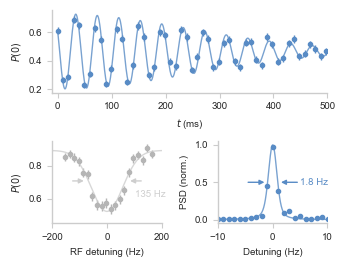

In [3]:
%matplotlib notebook
from matplotlib.gridspec import GridSpec

# Axes layout
plot_error = True
markersize = 3
fit_alpha = 0.8

ENES_color = '#588bc5'
grey_color = cm.Greys(0.3)

# Make figure
fig = plt.figure(figsize=[8.8/2.54, 6.8/2.54]) 
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax_PSD = fig.add_subplot(gs[1, 1])
ax_SEDOR = fig.add_subplot(gs[1, 0])

# Electron-nuclear double resonance
ax1.plot(data['T2']['x_fit'], data['T2']['y_fit'] ,  color = ENES_color, alpha = fit_alpha)
ax1.errorbar(data['T2']['x_vals'], data['T2']['y_vals'] , data['T2']['y_err_vals'], fmt = 'o', color = ENES_color, markersize = markersize)

# Axes settings
ax1.set_xlabel('$t$ (ms)')
ax1.set_ylabel('$P(0)$')
ax1.set_xlim([-10,500])
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(color = axes_color )


# SEDOR spectroscopy
center_freq = data['T2_star']['fit_params_dict']['x0']
ax_SEDOR.errorbar((np.array(data['T2_star']['x_vals'])-center_freq)*1e3, data['T2_star']['y_vals'], data['T2_star']['y_err_vals'], color = cm.Greys(0.4), fmt = '.')
ax_SEDOR.plot((np.array(data['T2_star']['x_fit'])-center_freq)*1e3, data['T2_star']['y_fit'], color = grey_color, alpha = fit_alpha)

# Axes settings
ax_SEDOR.set_xlim([-200,200])
ax_SEDOR.set_ylim([0.45,0.95])
ax_SEDOR.set_xlabel('RF detuning (Hz)')#, fontsize= fontsize)
ax_SEDOR.set_ylabel('PSD (norm.)')#, fontsize= fontsize)
ax_SEDOR.grid(False)
ax_SEDOR.tick_params(color = axes_color )
ax_SEDOR.spines['top'].set_visible(False)
ax_SEDOR.spines['right'].set_visible(False)
ax_SEDOR.set_ylabel('$P(0)$')

# Add arrows
HM = (np.min(data['T2_star']['y_fit']) + np.max(data['T2_star']['y_fit']))/2
FWHM= 2* np.sqrt(2*np.log(2)) * data['T2_star']['fit_params_dict']['sigma'] * 1000

ax_SEDOR.annotate('', xy=(-1.1 * FWHM/2, HM),
             xytext=(-2 *FWHM/2, HM),
             arrowprops=dict(arrowstyle= '-|>', color=grey_color,lw=1.)
           )
ax_SEDOR.annotate('', xy=(1.1 * FWHM/2,HM),
             xytext=(2 *FWHM/2, HM),
             arrowprops=dict(arrowstyle= '-|>', color=grey_color,lw=1.)
           )
label = str(int(FWHM)) + ' Hz'
ax_SEDOR.annotate(label, xy=(-1.1 * FWHM/2,HM), color = grey_color,
             xytext=(1.5 *FWHM/2, HM-0.1),
           )

# electron-nuclear PSD
ax_PSD.plot(data['T2']['freq1_fit'], data['T2']['PSD1_fit'], color = ENES_color, alpha = fit_alpha)
ax_PSD.errorbar(data['T2']['freq1'], data['T2']['PSD1'], data['T2']['PSD1_error'], color = ENES_color,  fmt = 'o', markersize = markersize)

# Axes settings
ax_PSD.set_xlim([-10,10])

ax_PSD.set_xlabel('Detuning (Hz)')#, fontsize= fontsize)
ax_PSD.set_ylabel('PSD (norm.)')#, fontsize= fontsize)

ax_PSD.grid(False)
ax_PSD.spines['top'].set_visible(False)
ax_PSD.spines['right'].set_visible(False)
ax_PSD.tick_params(color = axes_color )


# Add arrows
ax_PSD.annotate('', xy=(-1, 0.5),
             xytext=(-5, 0.5),
             arrowprops=dict(arrowstyle= '-|>', color=ENES_color,lw=1.)
           )
ax_PSD.annotate('', xy=(1, 0.5),
             xytext=(5, 0.5),
             arrowprops=dict(arrowstyle= '-|>', color=ENES_color,lw=1.)
           )
ax_PSD.annotate('1.8 Hz', xy=(1, 0.5), color = ENES_color,
             xytext=(5, 0.47),
           )

plt.tight_layout()



### Save figure

In [4]:
plt.savefig('figure_3.pdf', bbox_inches='tight')